In [1]:
import pandas as pd

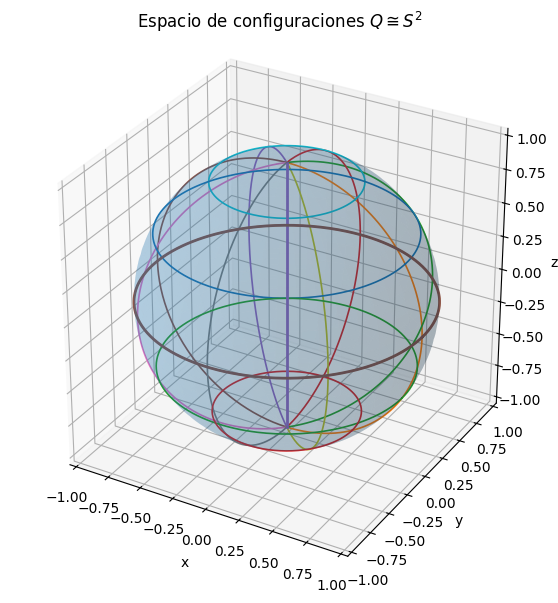

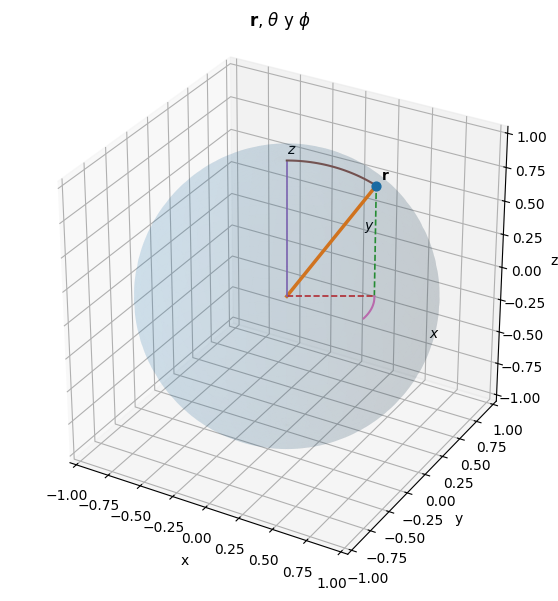

,theta_deg,phi_deg,x,y,z
0,20,0,3.420201e-01,0.000000,9.396926e-01
1,35,30,4.967318e-01,0.286788,8.191520e-01
2,60,45,6.123724e-01,0.612372,5.000000e-01
3,90,90,6.123234e-17,1.000000,6.123234e-17
4,120,30,7.500000e-01,0.433013,-5.000000e-01



Archivos guardados:
 - pendulo_S2.pdf/png
 - pendulo_croquis.pdf/png
 - coords_muestra.csv


In [3]:
# --- Péndulo esférico: configuración (S^2), croquis y tabla de ejemplo ---
# Esta celda:
#  - Muestra dos figuras (S^2 y croquis con r, theta, phi)
#  - Guarda pendulo_S2.(png|pdf), pendulo_croquis.(png|pdf)
#  - Crea coords_muestra.csv con (theta,phi)->(x,y,z)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para proyección 3D)

# ---------------- Parámetros editables ----------------
l = 1.0                 # longitud (radio de la esfera)
theta_vec_deg = 35      # ángulo con la vertical para el croquis (grados)
phi_vec_deg   = 30      # giro alrededor del eje z para el croquis (grados)

# ---------------- Utilidades ----------------
def spherical_to_cartesian(r, theta, phi):
    x = r*np.sin(theta)*np.cos(phi)
    y = r*np.sin(theta)*np.sin(phi)
    z = r*np.cos(theta)
    return x, y, z

def sphere_grid(r=1.0, n_theta=181, n_phi=361):
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2*np.pi, n_phi)
    TH, PH = np.meshgrid(theta, phi)
    X, Y, Z = spherical_to_cartesian(r, TH, PH)
    return X, Y, Z, theta, phi

# ======================================================
# Figura 1: Esfera (S^2) con meridianos y paralelos
# ======================================================
X, Y, Z, theta, _ = sphere_grid(l, 181, 361)

fig1 = plt.figure(figsize=(7,7))
ax1 = fig1.add_subplot(111, projection="3d")
ax1.plot_surface(X, Y, Z, alpha=0.18, linewidth=0, antialiased=True)

# meridianos
for ph in np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]):
    xm = l*np.sin(theta)*np.cos(ph)
    ym = l*np.sin(theta)*np.sin(ph)
    zm = l*np.cos(theta)
    ax1.plot(xm, ym, zm, linewidth=1.2)

# paralelos
phi_dense = np.linspace(0, 2*np.pi, 400)
for th in np.deg2rad([30, 60, 90, 120, 150]):
    xp = l*np.sin(th)*np.cos(phi_dense)
    yp = l*np.sin(th)*np.sin(phi_dense)
    zp = l*np.cos(th)*np.ones_like(phi_dense)
    ax1.plot(xp, yp, zp, linewidth=1.2)

# eje z y ecuador
ax1.plot([0,0], [0,0], [-l, l], linewidth=2.0)
ax1.plot(l*np.cos(phi_dense), l*np.sin(phi_dense), 0*phi_dense, linewidth=2.0)

ax1.set_box_aspect([1,1,1])
ax1.set_xlim([-1.05*l, 1.05*l]); ax1.set_ylim([-1.05*l, 1.05*l]); ax1.set_zlim([-1.05*l, 1.05*l])
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax1.set_title("Espacio de configuraciones $Q\\cong S^{2}$")

fig1.savefig("pendulo_S2.pdf", bbox_inches="tight")
fig1.savefig("pendulo_S2.png", dpi=300, bbox_inches="tight")
plt.show()

# ======================================================
# Figura 2: Croquis con r, theta y phi
# ======================================================
theta_vec = np.deg2rad(theta_vec_deg)
phi_vec   = np.deg2rad(phi_vec_deg)

fig2 = plt.figure(figsize=(7,7))
ax2 = fig2.add_subplot(111, projection="3d")
# esfera tenue
X2, Y2, Z2, _, _ = sphere_grid(l, 121, 241)
ax2.plot_surface(X2, Y2, Z2, alpha=0.10, linewidth=0, antialiased=True)

# vector r y su punta
xv, yv, zv = spherical_to_cartesian(l, theta_vec, phi_vec)
ax2.plot([0, xv], [0, yv], [0, zv], linewidth=2.5)
ax2.scatter([xv], [yv], [zv], s=40)

# guías
ax2.plot([xv, xv], [yv, yv], [0, zv], linestyle="--", linewidth=1.2)
ax2.plot([0, xv], [0, yv], [0, 0], linestyle="--", linewidth=1.2)
ax2.plot([0, 0], [0, 0], [0, l], linewidth=1.2)

# arco theta
thetas = np.linspace(0, theta_vec, 60)
x_th, y_th, z_th = spherical_to_cartesian(l, thetas, phi_vec)
ax2.plot(x_th, y_th, z_th, linewidth=1.5)

# arco phi (plano xy con radio l*sin(theta_vec))
phis = np.linspace(0, phi_vec, 60)
x_ph = l*np.sin(theta_vec)*np.cos(phis)
y_ph = l*np.sin(theta_vec)*np.sin(phis)
z_ph = 0*phis
ax2.plot(x_ph, y_ph, z_ph, linewidth=1.5)

ax2.text(xv*1.05, yv*1.05, zv*1.05, r"$\mathbf{r}$")
ax2.text(0, 0, 1.05*l, r"$z$")
ax2.text(1.05*l, 0, 0, r"$x$")
ax2.text(0, 1.05*l, 0, r"$y$")

ax2.set_box_aspect([1,1,1])
ax2.set_xlim([-1.05*l, 1.05*l]); ax2.set_ylim([-1.05*l, 1.05*l]); ax2.set_zlim([-1.05*l, 1.05*l])
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
ax2.set_title(r"$\mathbf{r}$, $\theta$ y $\phi$")

fig2.savefig("pendulo_croquis.pdf", bbox_inches="tight")
fig2.savefig("pendulo_croquis.png", dpi=300, bbox_inches="tight")
plt.show()

# ======================================================
# Tabla de ejemplo (pandas)
# ======================================================
deg = np.deg2rad
muestras = [(20, 0), (35, 30), (60, 45), (90, 90), (120, 30)]
filas = []
for th_deg, ph_deg in muestras:
    th = deg(th_deg); ph = deg(ph_deg)
    x, y, z = spherical_to_cartesian(l, th, ph)
    filas.append({"theta_deg": th_deg, "phi_deg": ph_deg, "x": x, "y": y, "z": z})

df = pd.DataFrame(filas)
display(df)  # se muestra bonito en VS Code/Jupyter
df.to_csv("coords_muestra.csv", index=False)

print("\nArchivos guardados:")
print(" - pendulo_S2.pdf/png")
print(" - pendulo_croquis.pdf/png")
print(" - coords_muestra.csv")
